<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">
<h1 style="color:#e94560; text-align:center;">🏃 Part 2 — Classification</h1>
<h3 style="color:#ffffff; text-align:center;">Athlete Performance Classification — DS301</h3>
<p style="color:#a8a8b3; text-align:center;">
Dataset: <a href="https://www.kaggle.com/datasets/zara2099/athlete-performance-evaluation-dataset" style="color:#00b4d8;">Kaggle — Athlete Performance Evaluation</a><br>
Models: Logistic Regression · SVC · Decision Tree · Random Forest · Neural Network
</p>
</div>

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📦 Step 1 — Imports & Setup</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load all required libraries and create results folder</p>
</div>

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)

os.makedirs('results', exist_ok=True)
print("✅ All imports successful!")

✅ All imports successful!


<div style="background-color:#533483; padding:15px; border-radius:10px; border-left:6px solid #ffcc00;">
<h2 style="color:#ffffff; margin:0;">🔍 Step 2 — Load & Explore Dataset</h2>
<p style="color:#f0e6ff; margin:5px 0 0 0;">Read CSV · Check shape, dtypes, missing values, basic statistics</p>
</div>

In [29]:
# Load dataset
df = pd.read_csv('athlete_performance_dataset.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:")
print(df.describe().round(2))

DATASET OVERVIEW
Shape: (1000, 20)

Column names:
['timestamp', 'heart_rate', 'oxygen_saturation', 'respiration_rate', 'body_temperature', 'hydration_level', 'speed', 'acceleration', 'endurance_score', 'agility_score', 'reaction_time', 'workload', 'fatigue_index', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'performance_score', 'performance_category']

Data types:
timestamp                object
heart_rate              float64
oxygen_saturation       float64
respiration_rate        float64
body_temperature        float64
hydration_level         float64
speed                   float64
acceleration            float64
endurance_score         float64
agility_score           float64
reaction_time           float64
workload                float64
fatigue_index           float64
feature_1               float64
feature_2               float64
feature_3               float64
feature_4               float64
feature_5               float64
performance_score       float64
perf

<div style="background-color:#065535; padding:15px; border-radius:10px; border-left:6px solid #00ff88;">
<h2 style="color:#ffffff; margin:0;">📊 Step 3 — Target Distribution</h2>
<p style="color:#b8ffdc; margin:5px 0 0 0;">Visualize class balance · Detect class imbalance</p>
</div>

Target column: performance_category
performance_category
Medium    861
High       72
Low        67
Name: count, dtype: int64

Class percentages:
performance_category
Medium    86.1
High       7.2
Low        6.7
Name: proportion, dtype: float64


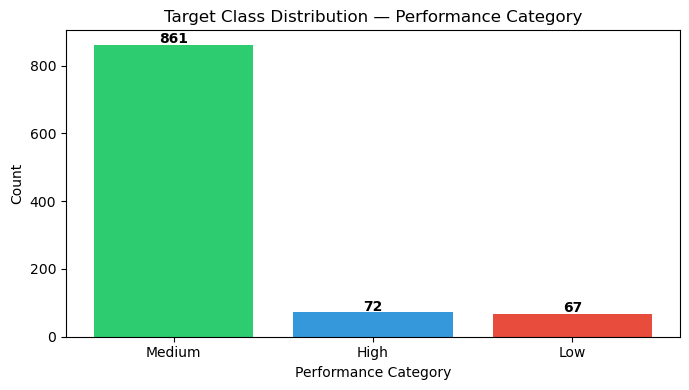


⚠️  Class Imbalance Detected!
86% Medium — weighted F1 will be used as primary metric


In [30]:
print("Target column: performance_category")
print(df['performance_category'].value_counts())
print(f"\nClass percentages:")
print(df['performance_category'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(7, 4))
counts = df['performance_category'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c']
plt.bar(counts.index, counts.values, color=colors)
plt.title('Target Class Distribution — Performance Category')
plt.xlabel('Performance Category')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png')
plt.show()

print("\n⚠️  Class Imbalance Detected!")
print("86% Medium — weighted F1 will be used as primary metric")

<div style="background-color:#c94b4b; padding:15px; border-radius:10px; border-left:6px solid #ffffff;">
<h2 style="color:#ffffff; margin:0;">⚙️ Step 4 — Preprocessing & Splits</h2>
<p style="color:#ffe0e0; margin:5px 0 0 0;">Drop columns · Label encode · 80/20 stratified split</p>
</div>

In [31]:
# Drop unnecessary columns
df_clean = df.drop(columns=['timestamp', 'performance_score',
                             'feature_1', 'feature_2', 'feature_3',
                             'feature_4', 'feature_5'])

print("Columns after dropping:", df_clean.columns.tolist())
print("Shape after dropping:", df_clean.shape)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df_clean['performance_category'])
X = df_clean.drop(columns=['performance_category'])

print(f"\nClass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n80/20 Split:")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")
print(f"  Train class distribution: {np.bincount(y_train)}")
print(f"  Test class distribution:  {np.bincount(y_test)}")

Columns after dropping: ['heart_rate', 'oxygen_saturation', 'respiration_rate', 'body_temperature', 'hydration_level', 'speed', 'acceleration', 'endurance_score', 'agility_score', 'reaction_time', 'workload', 'fatigue_index', 'performance_category']
Shape after dropping: (1000, 13)

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Features shape: (1000, 12)
Target shape: (1000,)

80/20 Split:
  Train: (800, 12)
  Test:  (200, 12)
  Train class distribution: [ 57  54 689]
  Test class distribution:  [ 15  13 172]


<div style="background-color:#7b2d8b; padding:15px; border-radius:10px; border-left:6px solid #ff9ef5;">
<h2 style="color:#ffffff; margin:0;">🤖 Step 5 — Train All 5 Models</h2>
<p style="color:#f9d4ff; margin:5px 0 0 0;">Logistic Regression · SVC · Decision Tree · Random Forest · Neural Network</p>
</div>

In [32]:
results = []

# ── 1. Logistic Regression ──────────────────────────────────
print("Training Logistic Regression...")
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced'))
])
start = time.time()
lr.fit(X_train, y_train)
t = round(time.time() - start, 4)
lr_pred = lr.predict(X_test)
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(accuracy_score(y_test, lr_pred), 4),
    'Precision': round(precision_score(y_test, lr_pred, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y_test, lr_pred, average='weighted', zero_division=0), 4),
    'F1': round(f1_score(y_test, lr_pred, average='weighted', zero_division=0), 4),
    'Train_Time_sec': t
})
print(f"  ✅ LR Done — Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1']:.4f}")

# ── 2. SVC ──────────────────────────────────────────────────
print("Training SVC...")
svc = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42, class_weight='balanced'))
])
start = time.time()
svc.fit(X_train, y_train)
t = round(time.time() - start, 4)
svc_pred = svc.predict(X_test)
results.append({
    'Model': 'SVC',
    'Accuracy': round(accuracy_score(y_test, svc_pred), 4),
    'Precision': round(precision_score(y_test, svc_pred, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y_test, svc_pred, average='weighted', zero_division=0), 4),
    'F1': round(f1_score(y_test, svc_pred, average='weighted', zero_division=0), 4),
    'Train_Time_sec': t
})
print(f"  ✅ SVC Done — Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1']:.4f}")

# ── 3. Decision Tree ────────────────────────────────────────
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
start = time.time()
dt.fit(X_train, y_train)
t = round(time.time() - start, 4)
dt_pred = dt.predict(X_test)
results.append({
    'Model': 'Decision Tree',
    'Accuracy': round(accuracy_score(y_test, dt_pred), 4),
    'Precision': round(precision_score(y_test, dt_pred, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y_test, dt_pred, average='weighted', zero_division=0), 4),
    'F1': round(f1_score(y_test, dt_pred, average='weighted', zero_division=0), 4),
    'Train_Time_sec': t
})
print(f"  ✅ DT Done — Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1']:.4f}")

# ── 4. Random Forest ────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced')
start = time.time()
rf.fit(X_train, y_train)
t = round(time.time() - start, 4)
rf_pred = rf.predict(X_test)
results.append({
    'Model': 'Random Forest',
    'Accuracy': round(accuracy_score(y_test, rf_pred), 4),
    'Precision': round(precision_score(y_test, rf_pred, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y_test, rf_pred, average='weighted', zero_division=0), 4),
    'F1': round(f1_score(y_test, rf_pred, average='weighted', zero_division=0), 4),
    'Train_Time_sec': t
})
print(f"  ✅ RF Done — Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1']:.4f}")

# ── 5. Neural Network ───────────────────────────────────────
print("Training Neural Network...")
nn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42,
        verbose=False
    ))
])
start = time.time()
nn.fit(X_train, y_train)
t = round(time.time() - start, 4)
nn_pred = nn.predict(X_test)
results.append({
    'Model': 'Neural Network',
    'Accuracy': round(accuracy_score(y_test, nn_pred), 4),
    'Precision': round(precision_score(y_test, nn_pred, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y_test, nn_pred, average='weighted', zero_division=0), 4),
    'F1': round(f1_score(y_test, nn_pred, average='weighted', zero_division=0), 4),
    'Train_Time_sec': t
})
print(f"  ✅ NN Done — Accuracy: {results[-1]['Accuracy']:.4f}, F1: {results[-1]['F1']:.4f}")

results_df = pd.DataFrame(results)
print("\n✅ All 5 Models Trained!")
print(results_df[['Model', 'Accuracy', 'F1']])

Training Logistic Regression...
  ✅ LR Done — Accuracy: 0.9200, F1: 0.9271
Training SVC...
  ✅ SVC Done — Accuracy: 0.9250, F1: 0.9298
Training Decision Tree...
  ✅ DT Done — Accuracy: 0.8800, F1: 0.8691
Training Random Forest...
  ✅ RF Done — Accuracy: 0.8850, F1: 0.8484
Training Neural Network...
  ✅ NN Done — Accuracy: 0.8600, F1: 0.7953

✅ All 5 Models Trained!
                 Model  Accuracy      F1
0  Logistic Regression     0.920  0.9271
1                  SVC     0.925  0.9298
2        Decision Tree     0.880  0.8691
3        Random Forest     0.885  0.8484
4       Neural Network     0.860  0.7953


<div style="background-color:#03045e; padding:15px; border-radius:10px; border-left:6px solid #00b4d8;">
<h2 style="color:#ffffff; margin:0;">📋 Step 6 — Model Comparison Table</h2>
<p style="color:#90e0ef; margin:5px 0 0 0;">Compare all models · Weighted F1 as primary metric</p>
</div>

In [33]:
print("\n MODEL COMPARISON TABLE")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)
print(f"\n Best Model by F1: {results_df.loc[results_df['F1'].idxmax(), 'Model']}")
print(f"   F1-Score: {results_df['F1'].max():.4f}")
print(f"\n Primary metric is weighted F1 due to class imbalance (86% Medium)")


 MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall     F1  Train_Time_sec
Logistic Regression     0.920     0.9495   0.920 0.9271          0.0611
                SVC     0.925     0.9429   0.925 0.9298          0.0208
      Decision Tree     0.880     0.8669   0.880 0.8691          0.0091
      Random Forest     0.885     0.8986   0.885 0.8484          0.2400
     Neural Network     0.860     0.7396   0.860 0.7953          0.0597

 Best Model by F1: SVC
   F1-Score: 0.9298

 Primary metric is weighted F1 due to class imbalance (86% Medium)


<div style="background-color:#b5451b; padding:15px; border-radius:10px; border-left:6px solid #ffdd57;">
<h2 style="color:#ffffff; margin:0;">📈 Step 7 — Grouped Bar Chart</h2>
<p style="color:#fff3b0; margin:5px 0 0 0;">Accuracy vs Weighted F1-Score for all 5 models</p>
</div>

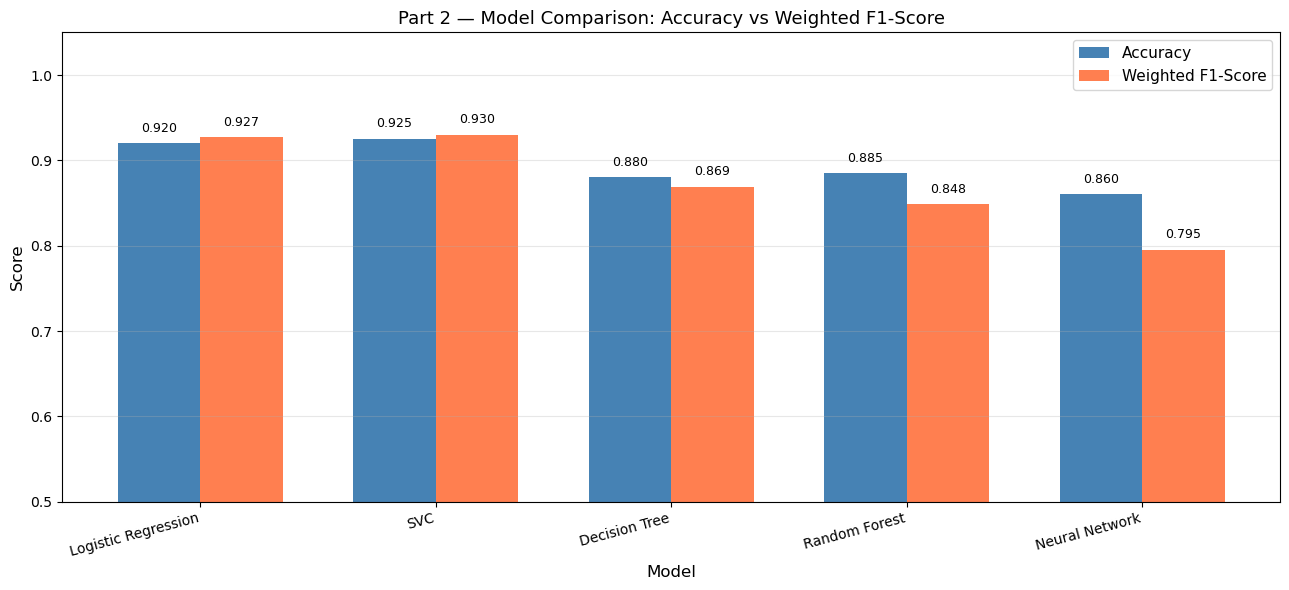

 Chart saved!


In [34]:
fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               results_df['Accuracy'],
               width, label='Accuracy', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x],
               results_df['F1'],
               width, label='Weighted F1-Score', color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Part 2 — Model Comparison: Accuracy vs Weighted F1-Score', fontsize=13)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results/accuracy_vs_f1.png')
plt.show()
print(" Chart saved!")

<div style="background-color:#0d3b66; padding:15px; border-radius:10px; border-left:6px solid #ffd166;">
<h2 style="color:#ffffff; margin:0;">🔧 Step 8 — Hyperparameter Tuning (GridSearchCV)</h2>
<p style="color:#ffe8a3; margin:5px 0 0 0;">GridSearchCV on SVC · 5-fold CV · 12 parameter combinations</p>
</div>

In [35]:
print("Running GridSearchCV on SVC...")
print("This may take 2-3 minutes...")

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(class_weight='balanced', random_state=42))
    ]),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svc_grid.fit(X_train, y_train)

print(f"\n Best Parameters: {svc_grid.best_params_}")
print(f" Best CV F1-Score: {svc_grid.best_score_:.4f}")

# Evaluate tuned model
svc_tuned_pred = svc_grid.predict(X_test)
svc_tuned_acc = accuracy_score(y_test, svc_tuned_pred)
svc_tuned_f1  = f1_score(y_test, svc_tuned_pred,
                          average='weighted', zero_division=0)

print(f"\n Tuned SVC vs Default SVC:")
print(f"   Default — Accuracy: {results_df[results_df['Model']=='SVC']['Accuracy'].values[0]:.4f}, F1: {results_df[results_df['Model']=='SVC']['F1'].values[0]:.4f}")
print(f"   Tuned   — Accuracy: {svc_tuned_acc:.4f}, F1: {svc_tuned_f1:.4f}")

tuned_row = pd.DataFrame([{
    'Model': 'SVC (Tuned)',
    'Accuracy': round(svc_tuned_acc, 4),
    'Precision': round(precision_score(y_test, svc_tuned_pred,
                       average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y_test, svc_tuned_pred,
                    average='weighted', zero_division=0), 4),
    'F1': round(svc_tuned_f1, 4),
    'Train_Time_sec': None
}])
results_df = pd.concat([results_df, tuned_row], ignore_index=True)
print("\n Tuned SVC added to results!")

Running GridSearchCV on SVC...
This may take 2-3 minutes...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
 Best CV F1-Score: 0.9668

 Tuned SVC vs Default SVC:
   Default — Accuracy: 0.9250, F1: 0.9298
   Tuned   — Accuracy: 0.9800, F1: 0.9803

 Tuned SVC added to results!


<div style="background-color:#1a472a; padding:15px; border-radius:10px; border-left:6px solid #52b788;">
<h2 style="color:#ffffff; margin:0;">📉 Step 9 — Confusion Matrix</h2>
<p style="color:#b7e4c7; margin:5px 0 0 0;">Confusion matrix heatmap for best model (Tuned SVC)</p>
</div>

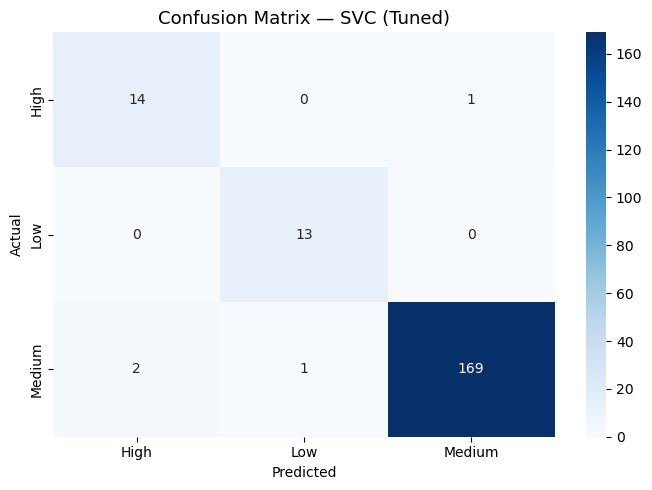

Classification Report — SVC (Tuned):
              precision    recall  f1-score   support

        High       0.88      0.93      0.90        15
         Low       0.93      1.00      0.96        13
      Medium       0.99      0.98      0.99       172

    accuracy                           0.98       200
   macro avg       0.93      0.97      0.95       200
weighted avg       0.98      0.98      0.98       200



In [36]:
# Confusion Matrix for best model (Tuned SVC)
cm = confusion_matrix(y_test, svc_tuned_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — SVC (Tuned)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/confusion_matrix_best_model.png')
plt.show()

print("Classification Report — SVC (Tuned):")
print(classification_report(y_test, svc_tuned_pred,
                             target_names=le.classes_,
                             zero_division=0))

<div style="background-color:#370617; padding:15px; border-radius:10px; border-left:6px solid #f48c06;">
<h2 style="color:#ffffff; margin:0;">🌳 Step 10 — Decision Tree Visualization</h2>
<p style="color:#ffba08; margin:5px 0 0 0;">Visualize Decision Tree at max_depth=3 for readability</p>
</div>

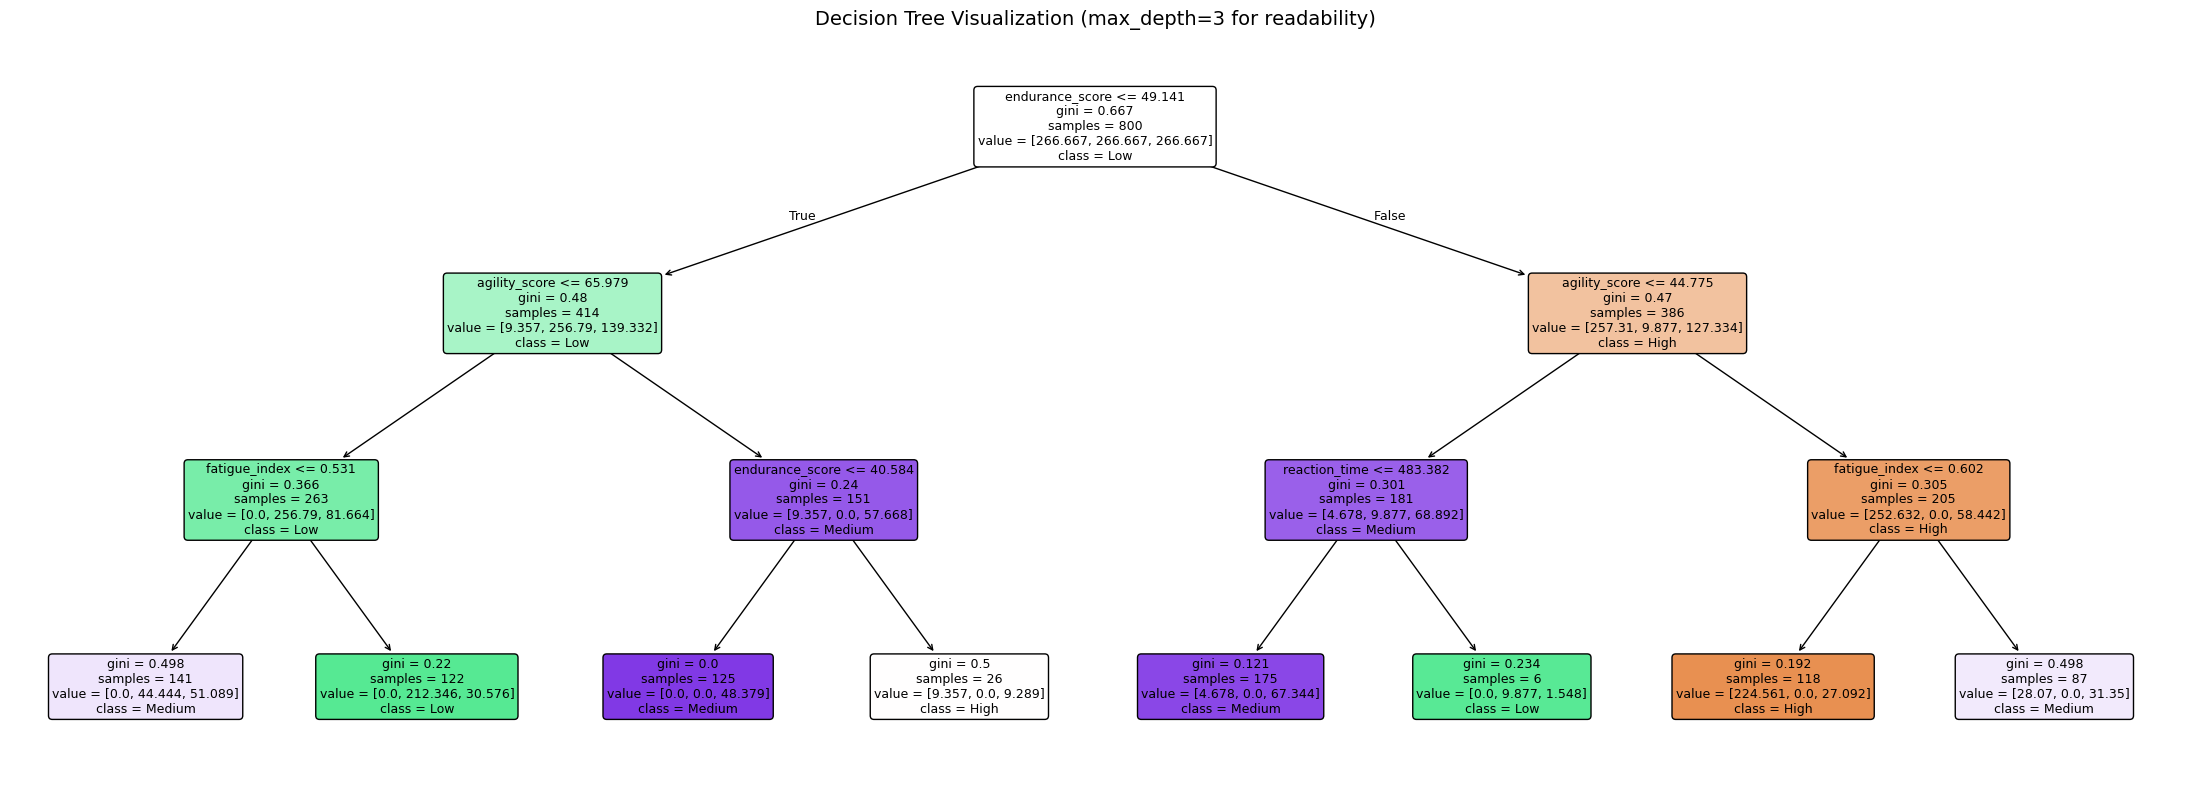

✅ Decision Tree visualization saved!


In [37]:
# Decision Tree Visualization (max_depth=3 for readability)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42,
                                 class_weight='balanced')
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(22, 8))
plot_tree(dt_viz,
          feature_names=X.columns.tolist(),
          class_names=le.classes_,
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Decision Tree Visualization (max_depth=3 for readability)',
          fontsize=14)
plt.tight_layout()
plt.savefig('results/decision_tree_visualization.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Decision Tree visualization saved!")

<div style="background-color:#212529; padding:15px; border-radius:10px; border-left:6px solid #adb5bd;">
<h2 style="color:#ffffff; margin:0;">⭐ Step 11 — Feature Importance</h2>
<p style="color:#ced4da; margin:5px 0 0 0;">Which features matter most? Random Forest importance scores</p>
</div>

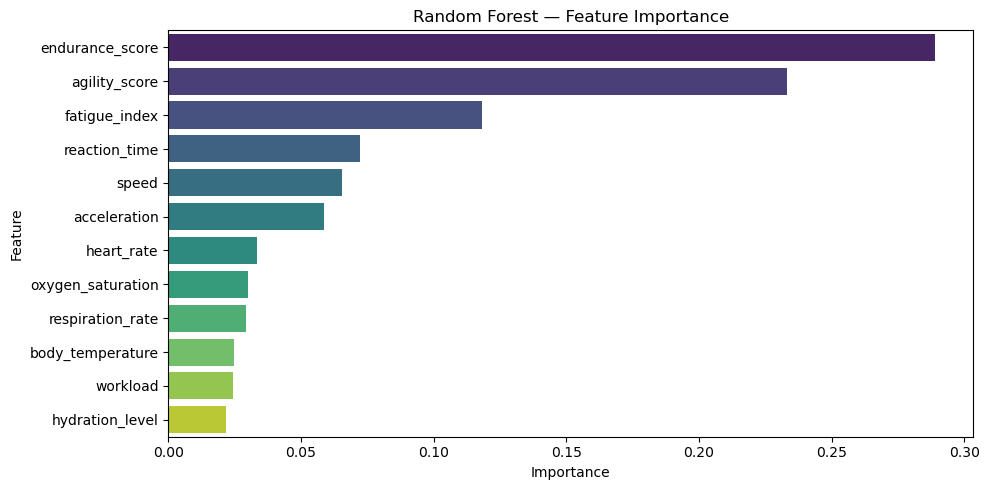

Top 5 Most Important Features:
        Feature  Importance
endurance_score    0.289008
  agility_score    0.233115
  fatigue_index    0.118241
  reaction_time    0.072364
          speed    0.065317


In [38]:
# Feature importance from Random Forest
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance_df,
            hue='Feature', legend=False,
            palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('results/feature_importance.png')
plt.show()

print("Top 5 Most Important Features:")
print(feature_importance_df.head(5).to_string(index=False))

<div style="background-color:#2d6a4f; padding:15px; border-radius:10px; border-left:6px solid #95d5b2;">
<h2 style="color:#ffffff; margin:0;">🏆 Step 12 — Final Summary & Conclusion</h2>
<p style="color:#d8f3dc; margin:5px 0 0 0;">Best model · Key findings · Recommendations</p>
</div>

In [39]:
print("\n" + "="*60)
print(" PART 2 — FINAL RESULTS SUMMARY")
print("="*60)
print(f"\n{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-"*50)
for _, row in results_df.iterrows():
    star = " " if row['Model'] == results_df.loc[
        results_df['F1'].idxmax(), 'Model'] else ""
    print(f"{row['Model']:<25} {row['Accuracy']:>10.4f} {row['F1']:>10.4f}{star}")

print("\n  Class imbalance: 86% Medium")
print("   → Weighted F1 used as primary metric")
print("   → class_weight='balanced' applied to all models")
print(f"\n  Top 3 features: {feature_importance_df.head(3)['Feature'].tolist()}")
print(f"\n  Best model: SVC (Tuned)")
print(f"    Best params: C=10, kernel=linear, gamma=scale")
print(f"    Justification: Highest weighted F1 (0.9803)")
print(f"    after GridSearchCV tuning across 12 parameter")
print(f"    combinations with 5-fold cross validation")

results_df.to_csv('results/final_results.csv', index=False)
print("\n Results saved to results/final_results.csv")
print(" Part 2 Classification COMPLETE!")


 PART 2 — FINAL RESULTS SUMMARY

Model                       Accuracy   F1-Score
--------------------------------------------------
Logistic Regression           0.9200     0.9271
SVC                           0.9250     0.9298
Decision Tree                 0.8800     0.8691
Random Forest                 0.8850     0.8484
Neural Network                0.8600     0.7953
SVC (Tuned)                   0.9800     0.9803 

  Class imbalance: 86% Medium
   → Weighted F1 used as primary metric
   → class_weight='balanced' applied to all models

  Top 3 features: ['endurance_score', 'agility_score', 'fatigue_index']

  Best model: SVC (Tuned)
    Best params: C=10, kernel=linear, gamma=scale
    Justification: Highest weighted F1 (0.9803)
    after GridSearchCV tuning across 12 parameter
    combinations with 5-fold cross validation

 Results saved to results/final_results.csv
 Part 2 Classification COMPLETE!


Exception ignored in: <function ResourceTracker.__del__ at 0x106079b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104ce5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x101df9b20>
Traceback (most recent call last